In [1]:
%pip install numpy pandas scikit-learn matplotlib seaborn -q


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

2. Load Data & clean

In [19]:
df=pd.read_csv("breast_cancer_dataset.csv")

In [22]:
df.shape

(569, 32)

In [24]:
df.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
214,8810955,M,14.19,23.81,92.87,610.7,0.09463,0.13060,0.111500,0.064620,0.2235,0.06433,0.4207,1.8450,3.534,31.00,0.010880,0.037100,0.036880,0.016270,0.04499,0.004768,16.86,34.85,115.00,811.3,0.1559,0.40590,0.37440,0.17720,0.4724,0.10260
78,8610862,M,20.18,23.97,143.70,1245.0,0.12860,0.34540,0.375400,0.160400,0.2906,0.08142,0.9317,1.8850,8.649,116.40,0.010380,0.068350,0.109100,0.025930,0.07895,0.005987,23.37,31.72,170.30,1623.0,0.1639,0.61640,0.76810,0.25080,0.5440,0.09964
85,8612399,M,18.46,18.52,121.10,1075.0,0.09874,0.10530,0.133500,0.087950,0.2132,0.06022,0.6997,1.4750,4.782,80.60,0.006471,0.016490,0.028060,0.014200,0.02370,0.003755,22.93,27.68,152.20,1603.0,0.1398,0.20890,0.31570,0.16420,0.3695,0.08579
31,853612,M,11.84,18.70,77.93,440.6,0.11090,0.15160,0.121800,0.051820,0.2301,0.07799,0.4825,1.0300,3.475,41.00,0.005551,0.034140,0.042050,0.010440,0.02273,0.005667,16.82,28.12,119.40,888.7,0.1637,0.57750,0.69560,0.15460,0.4761,0.14020
309,893548,B,13.05,13.84,82.71,530.6,0.08352,0.03735,0.004559,0.008829,0.1453,0.05518,0.3975,0.8285,2.567,33.01,0.004148,0.004711,0.002831,0.004821,0.01422,0.002273,14.73,17.40,93.96,672.4,0.1016,0.05847,0.01824,0.03532,0.2107,0.06580


In [25]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [29]:
df["diagnosis"].value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

In [30]:
df["diagnosis"]=df["diagnosis"].map({"B":0,"M":1})  

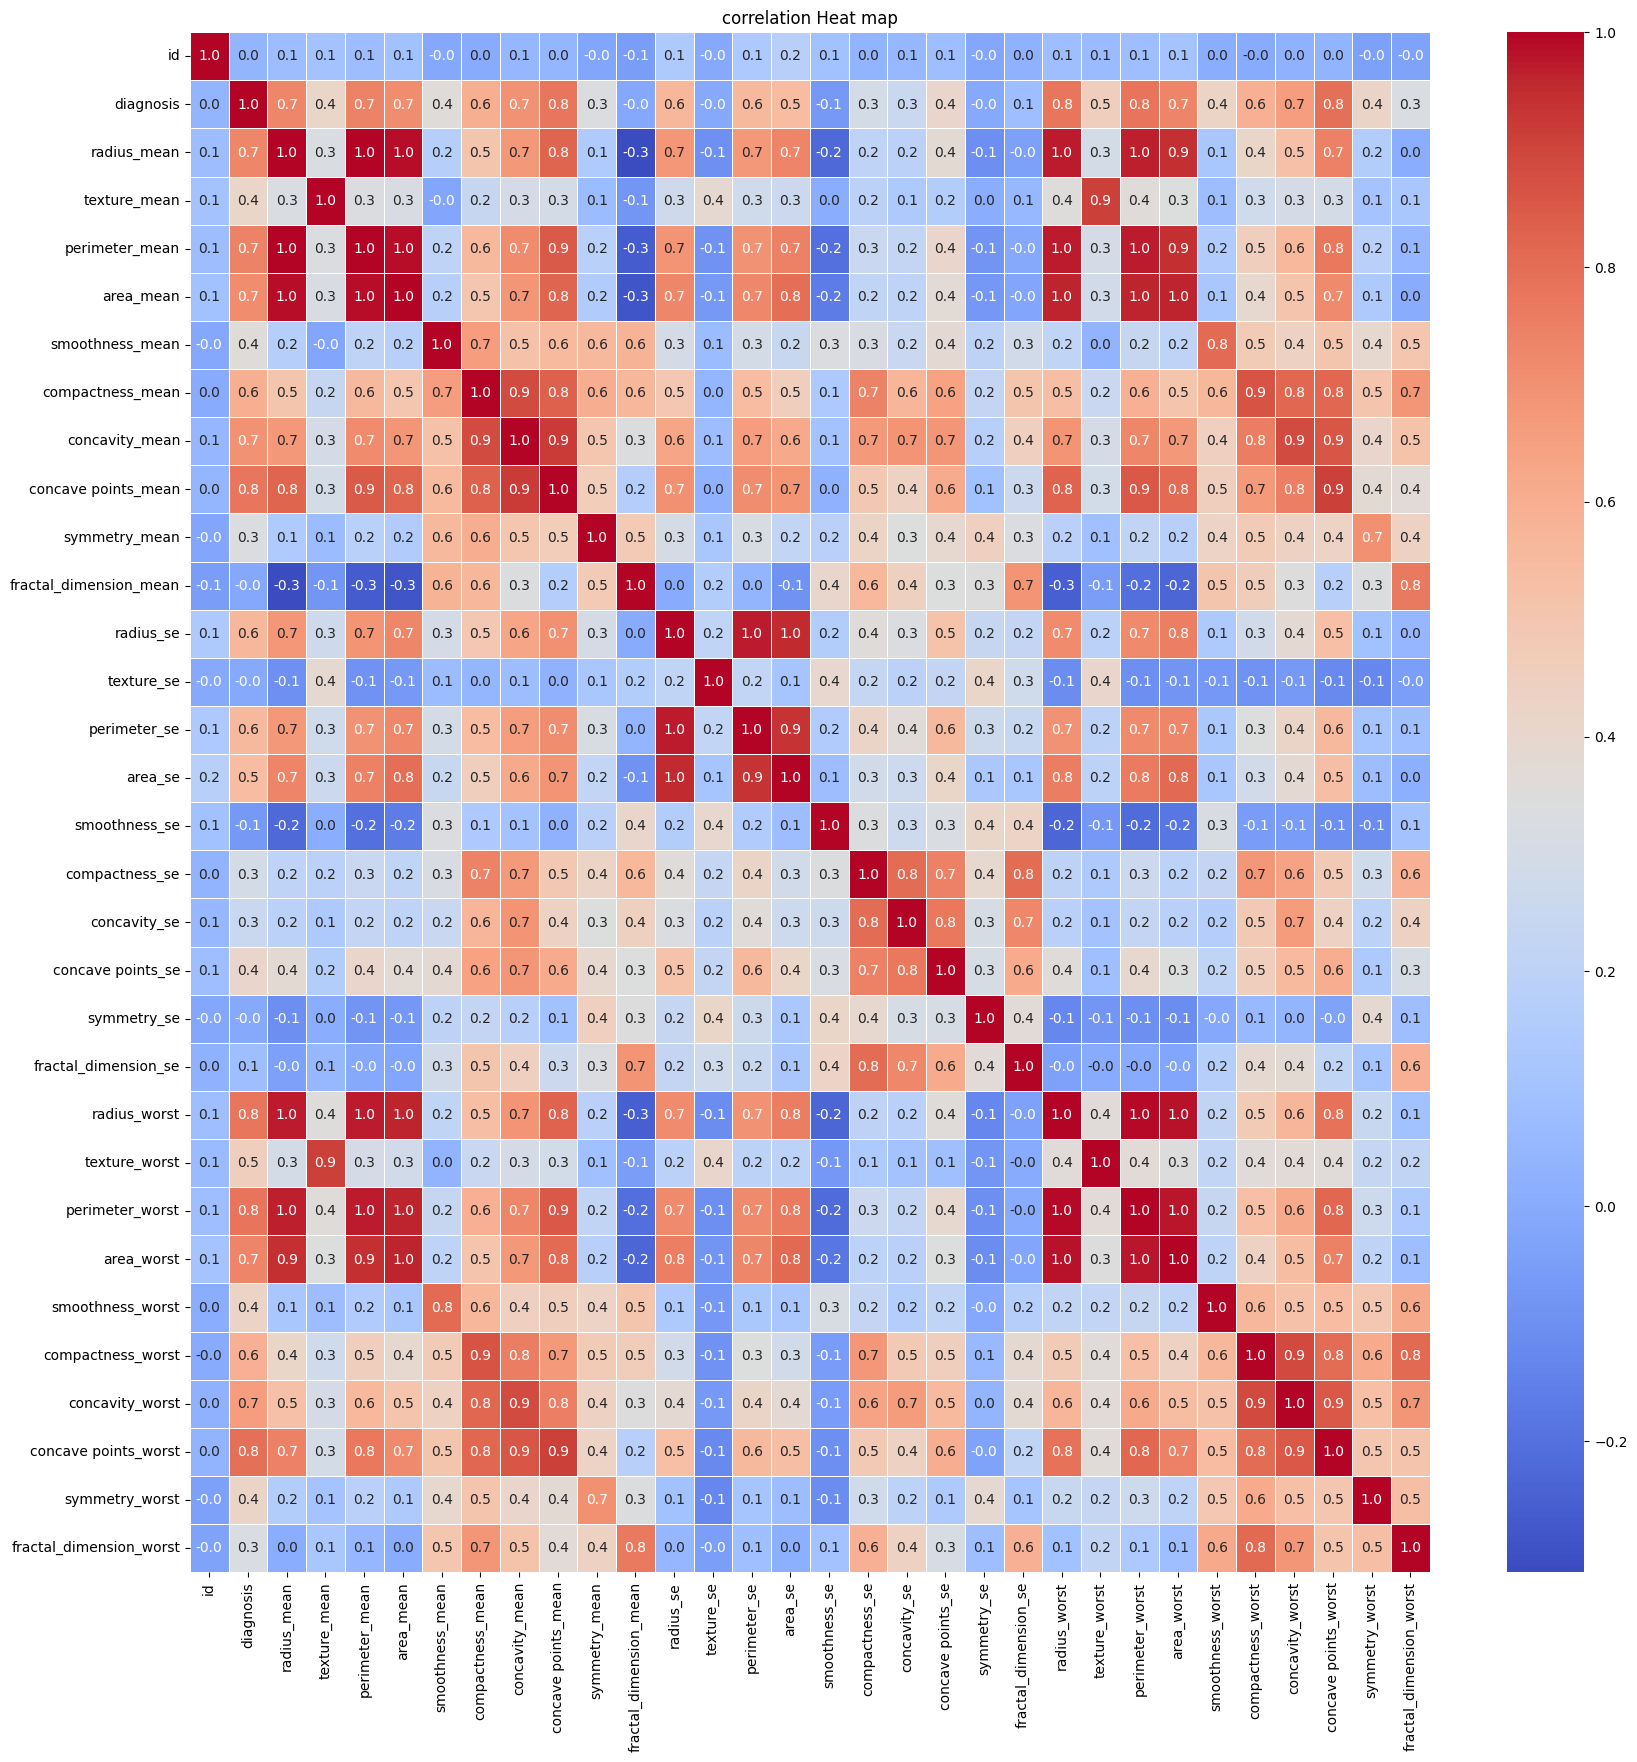

In [36]:
df_corr=df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(df_corr,annot=True,cmap="coolwarm",fmt=".1f",linewidth=0.5,cbar=True)
plt.title("correlation Heat map")
plt.show()

NoTE : There are presence of highly correlated features

In [37]:
x=df.drop(columns=["id","diagnosis"])
y=df["diagnosis"]

In [38]:
x.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


TRAIN_TEST_SPLIT

In [39]:
X_train,X_test,y_train,y_test=train_test_split(
    x,y,stratify=y,random_state=42,test_size=.2
)

In [41]:
print(X_train.shape)
print(X_test.shape)


(455, 30)
(114, 30)


Features Selection Process

In [60]:
#helper function to print train and test metrics
def print_metrics(name,model,Xtr,Xte,ytr,yte):
    #get predication
    tr_pred=model.predict(Xtr)
    te_pred=model.predict(Xte)
    tr_acc=accuracy_score(ytr,tr_pred)
    te_acc=accuracy_score(yte,te_pred)
    print(name)
    print(f"Train Accuracy {(tr_acc)*100,2}%")
    print(f"Test Accuracy {te_acc*100}%")
    
    
    


Base line model means no featues removed

In [50]:
baseline_pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("model",LogisticRegression())
])

In [54]:
baseline_pipe.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [61]:
print_metrics(
    name="baseline",
    model=baseline_pipe,
    Xtr=X_train,
    Xte=X_test,
    ytr=y_train,
    yte=y_test
)

baseline
Train Accuracy (98.68131868131869, 2)%
Test Accuracy 96.49122807017544%


Filter method :Correlation ///wrapper method ,REF method

In [62]:
corr=X_train.corr().abs() # Identify both highly positively correlated and negatively correlated columns

In [63]:
corr

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.326358,0.997815,0.986740,0.188805,0.526901,0.676323,0.826984,0.148416,0.294777,0.678727,0.074570,0.674580,0.729469,0.186078,0.232128,0.186558,0.378684,0.075719,0.024908,0.969256,0.303891,0.964439,0.940515,0.124912,0.417638,0.515938,0.741073,0.151632,0.010712
texture_mean,0.326358,1.000000,0.331800,0.318811,0.011749,0.246818,0.292341,0.289028,0.089454,0.068576,0.261062,0.382567,0.266603,0.243553,0.017520,0.199001,0.126090,0.169595,0.010040,0.058216,0.350573,0.911671,0.356590,0.336349,0.075855,0.282338,0.289614,0.288636,0.114120,0.126669
perimeter_mean,0.997815,0.331800,1.000000,0.985960,0.225840,0.577536,0.716044,0.855414,0.185686,0.244184,0.692054,0.063998,0.694109,0.739116,0.166166,0.276872,0.219881,0.409508,0.051645,0.011057,0.969332,0.309888,0.970006,0.941085,0.155970,0.460088,0.553325,0.768021,0.178037,0.053990
area_mean,0.986740,0.318811,0.985960,1.000000,0.200033,0.518185,0.685587,0.827092,0.154040,0.264658,0.731883,0.043825,0.726519,0.795706,0.128277,0.237054,0.199874,0.373269,0.046329,0.004133,0.960725,0.290117,0.956714,0.958177,0.133316,0.393840,0.501422,0.717781,0.131099,0.008730
smoothness_mean,0.188805,0.011749,0.225840,0.200033,1.000000,0.668208,0.540455,0.570760,0.558946,0.592764,0.323464,0.026994,0.315289,0.267939,0.329556,0.309327,0.241829,0.368412,0.182429,0.264116,0.243269,0.060610,0.269934,0.237707,0.824095,0.492120,0.453733,0.531333,0.415142,0.509334
compactness_mean,0.526901,0.246818,0.577536,0.518185,0.668208,1.000000,0.892790,0.845809,0.608154,0.560300,0.513541,0.050368,0.564665,0.466179,0.137354,0.733488,0.550324,0.639993,0.241224,0.491543,0.559706,0.264249,0.615411,0.530403,0.569264,0.867360,0.820215,0.828208,0.512286,0.675986
concavity_mean,0.676323,0.292341,0.716044,0.685587,0.540455,0.892790,1.000000,0.920598,0.514502,0.358402,0.631220,0.084487,0.658933,0.613761,0.119743,0.691621,0.683525,0.684569,0.201845,0.469689,0.688777,0.296746,0.731725,0.675319,0.452000,0.759892,0.878816,0.857881,0.410384,0.521660
concave points_mean,0.826984,0.289028,0.855414,0.827092,0.570760,0.845809,0.920598,1.000000,0.479263,0.183271,0.697586,0.020112,0.708650,0.685837,0.044668,0.506001,0.426605,0.610034,0.120758,0.261261,0.838067,0.298276,0.864362,0.815747,0.458986,0.676361,0.746509,0.912250,0.384501,0.372876
symmetry_mean,0.148416,0.089454,0.185686,0.154040,0.558946,0.608154,0.514502,0.479263,1.000000,0.496995,0.311663,0.129987,0.326960,0.228186,0.215386,0.440840,0.344418,0.416558,0.451956,0.340059,0.195371,0.115193,0.231960,0.186780,0.440022,0.480185,0.434807,0.448602,0.706311,0.447477
fractal_dimension_mean,0.294777,0.068576,0.244184,0.264658,0.592764,0.560300,0.358402,0.183271,0.496995,1.000000,0.017740,0.154491,0.056218,0.071792,0.371365,0.546283,0.458965,0.357134,0.332837,0.664750,0.230020,0.037014,0.179904,0.209438,0.517282,0.473458,0.375302,0.202556,0.358654,0.771813


In [72]:
to_drop=set()

for i in range(len(corr.columns)):
    for j in range(i):
        if corr.iloc[i,j]>0.9:
            to_drop.add(corr.columns[i])
            
print(to_drop)
selected_filter=[col for col in X_train.columns if col not in to_drop]
# print("Selected columns: ", Selected_filter)
print("Selected columns:",selected_filter)

{'radius_worst', 'texture_worst', 'area_mean', 'concave points_mean', 'area_se', 'perimeter_mean', 'perimeter_worst', 'area_worst', 'perimeter_se', 'concave points_worst'}
Selected columns: ['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [74]:
X_train_f=X_train[selected_filter]
X_test_f=X_test[selected_filter]

In [75]:
filterpipe=Pipeline([
     ("scaler",StandardScaler()),
    ("model",LogisticRegression())
])
    


In [77]:
filterpipe.fit(X_train_f,y_train)




,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['radius_mean','texture_mean','smoothness_mean',...,'concavity_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [79]:
print_metrics(
    name="baseline features with removed features",
    model=filterpipe,
    Xtr=X_train_f,
    Xte=X_test_f,
    ytr=y_train,
    yte=y_test
)

baseline features with removed features
Train Accuracy (98.68131868131869, 2)%
Test Accuracy 97.36842105263158%


In [81]:
X_train_f

,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
10,16.02,23.24,0.08206,0.06669,0.03299,0.1528,0.05697,0.3795,1.1870,0.004029,0.009269,0.011010,0.007591,0.01460,0.003042,0.11810,0.15510,0.14590,0.2948,0.08452
170,12.32,12.39,0.10280,0.06981,0.03987,0.1959,0.05955,0.2360,0.6656,0.008045,0.011800,0.016830,0.012410,0.01924,0.002248,0.13850,0.12660,0.12420,0.2827,0.06771
407,12.85,21.37,0.07551,0.08316,0.06126,0.1580,0.06114,0.4993,1.7980,0.006011,0.044800,0.051750,0.013410,0.02669,0.007731,0.09402,0.19360,0.18380,0.2488,0.08151
430,14.90,22.53,0.09947,0.22250,0.27330,0.2041,0.06898,0.2530,0.8749,0.006965,0.062130,0.079260,0.022340,0.01499,0.005784,0.14190,0.70900,0.90190,0.2866,0.11550
27,18.61,20.25,0.09440,0.10660,0.14900,0.1697,0.05699,0.8529,1.8490,0.010750,0.027220,0.050810,0.019110,0.02293,0.004217,0.13380,0.21170,0.34460,0.2341,0.07421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,13.03,18.42,0.08983,0.03766,0.02562,0.1467,0.05863,0.1839,2.3420,0.004352,0.004899,0.013430,0.011640,0.02671,0.001777,0.09701,0.04619,0.04833,0.1987,0.06169
415,11.89,21.17,0.09773,0.08120,0.02555,0.2019,0.06290,0.2747,1.2030,0.009895,0.030530,0.016300,0.009276,0.02258,0.002272,0.14260,0.21870,0.11640,0.3075,0.07351
458,13.00,25.13,0.08369,0.05073,0.01206,0.1667,0.05449,0.2621,1.2320,0.006054,0.008974,0.005681,0.006336,0.01215,0.001514,0.12180,0.10930,0.04462,0.2306,0.06291
476,14.20,20.53,0.08931,0.11080,0.05063,0.1506,0.06009,0.3478,1.0180,0.004107,0.032880,0.028210,0.013500,0.01610,0.002744,0.11530,0.34290,0.25120,0.2534,0.07858


In [80]:
df_corr_f=X_train_f

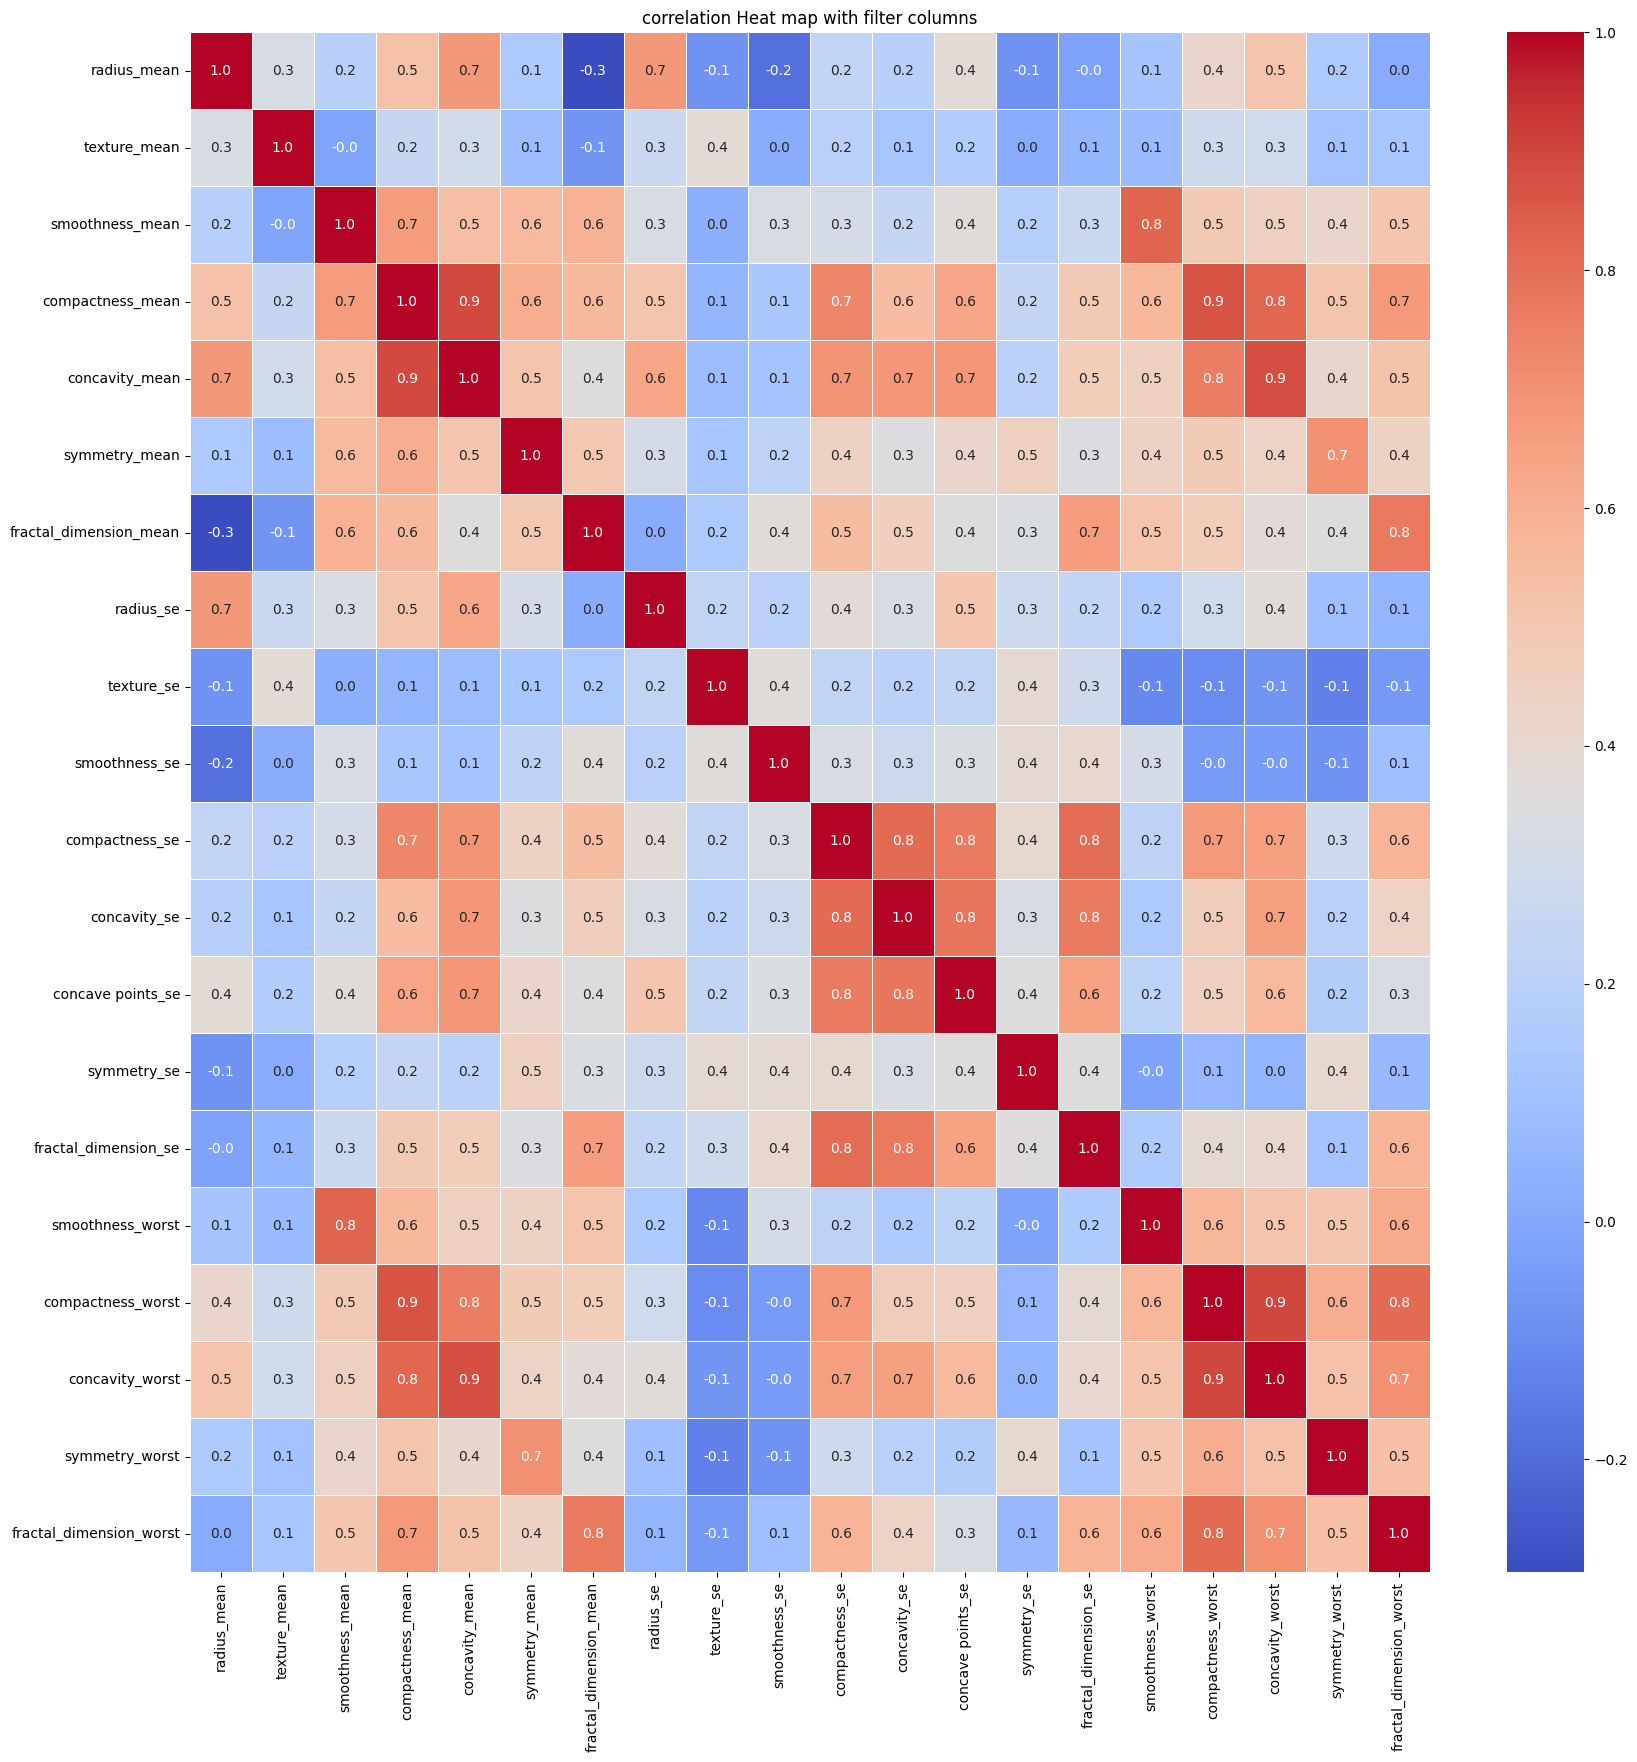

In [82]:
df_corr=df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(df_corr_f.corr(),annot=True,cmap="coolwarm",fmt=".1f",linewidth=0.5,cbar=True)
plt.title("correlation Heat map with filter columns")
plt.show()